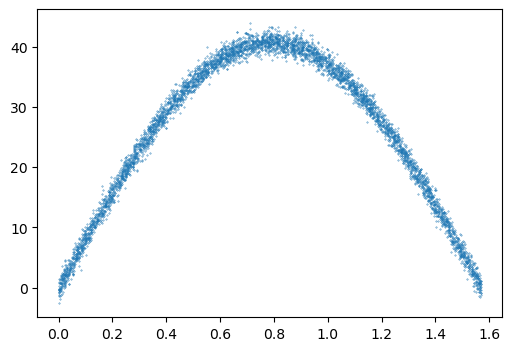

 Neural network successfully converged after 91 epochs.

5095it [00:00, 344366.04it/s]           


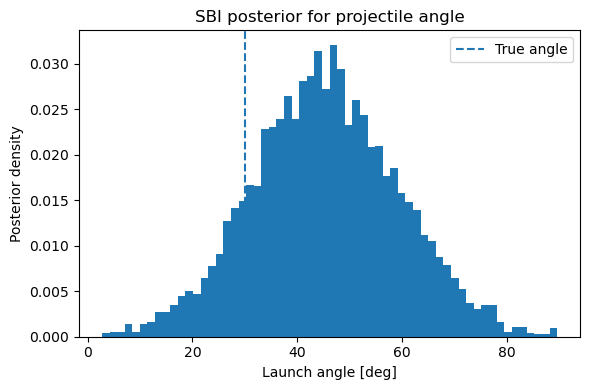

In [13]:
import torch
import matplotlib.pyplot as plt

from sbi.inference import NPE
from sbi.utils import BoxUniform
from sbi.analysis import pairplot


# -------------------------
# Simulator
# -------------------------

g = 9.81
v0 = 20.0


def simulator(theta):
    """
    theta in radians
    returns projectile range
    """
    noise = 1.0 * torch.randn(1)

    R = v0**2 / g * torch.sin(2 * theta)

    return R + noise


# -------------------------
# Prior
# -------------------------

prior = BoxUniform(
    low=torch.tensor([0.0]),
    high=torch.tensor([torch.pi / 2]),
)

# -------------------------
# Generate training data
# -------------------------

num_simulations = 5000

theta = prior.sample((num_simulations,))
x = torch.stack([simulator(t) for t in theta])

plt.figure(figsize=(6, 4))
plt.scatter(theta, x, s=0.1)
plt.show()

# -------------------------
# Train NPE
# -------------------------

inference = NPE(prior=prior)
inference.append_simulations(theta, x)

density_estimator = inference.train()

posterior = inference.build_posterior(
    density_estimator
)

# -------------------------
# Observation
# -------------------------

theta_true = torch.tensor([torch.deg2rad(torch.tensor(30.0))])

x_obs = simulator(theta_true)

# -------------------------
# Posterior samples
# -------------------------

samples = posterior.sample(
    (5000,),
    x=x_obs
)

# -------------------------
# Plot
# -------------------------

plt.figure(figsize=(6, 4))

plt.hist(
    samples.numpy() * 180 / torch.pi,
    bins=60,
    density=True
)

plt.axvline(
    30,
    linestyle="--",
    label="True angle"
)

plt.xlabel("Launch angle [deg]")
plt.ylabel("Posterior density")
plt.title("SBI posterior for projectile angle")
plt.legend()

plt.tight_layout()
plt.show()